In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# K-Means
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Evaluation Metrics
from sklearn.metrics import silhouette_score

In [2]:
# Setup path
BASE_PATH = 'dataset'
OUTPUT_FOLDER = os.path.join(BASE_PATH, 'output_pipeline')
ARTIFACTS_FOLDER = os.path.join(BASE_PATH, 'artifacts')
MODEL_FOLDER = os.path.join(BASE_PATH, 'model_outputs')
EDA_FOLDER = os.path.join(BASE_PATH, 'eda_outputs')

In [3]:
# Load fitur (X)
X_train = pd.read_parquet(os.path.join(OUTPUT_FOLDER, 'stage6_X_train.parquet'))
X_val = pd.read_parquet(os.path.join(OUTPUT_FOLDER, 'stage6_X_val.parquet'))
X_test = pd.read_parquet(os.path.join(OUTPUT_FOLDER, 'stage6_X_test.parquet'))

In [4]:
# Load target (y) - convert ke Series untuk sklearn
y_train = pd.read_parquet(os.path.join(OUTPUT_FOLDER, 'stage6_y_train.parquet'))
y_val = pd.read_parquet(os.path.join(OUTPUT_FOLDER, 'stage6_y_val.parquet'))
y_test = pd.read_parquet(os.path.join(OUTPUT_FOLDER, 'stage6_y_test.parquet'))

In [5]:
# Load metadata ID (untuk traceback hasil prediksi nanti)
ID_train = pd.read_parquet(os.path.join(OUTPUT_FOLDER, 'stage6_ID_train.parquet'))
ID_val = pd.read_parquet(os.path.join(OUTPUT_FOLDER, 'stage6_ID_val.parquet'))
ID_test = pd.read_parquet(os.path.join(OUTPUT_FOLDER, 'stage6_ID_test.parquet'))

In [6]:
scaler = joblib.load(os.path.join(ARTIFACTS_FOLDER, 'minmax_scaler.joblib'))
winsor = joblib.load(os.path.join(ARTIFACTS_FOLDER, 'winsor_bounds.joblib'))
feat_select = joblib.load(os.path.join(ARTIFACTS_FOLDER, 'feature_selection_info.joblib'))

/home/aliarridha/miniconda3/envs/modeling1/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [7]:
# Display Feature Selection Info
print('=== FEATURE SELECTION INFO ===')
print(f'Tipe: {type(feat_select)}')
print(f'\nIsi: ')
if isinstance(feat_select, dict):
    print(feat_select)
elif isinstance(feat_select, list):
    print(f'Jumlah fitur: {len(feat_select)}')
    print(feat_select)
else:
    print(feat_select)

=== FEATURE SELECTION INFO ===
Tipe: <class 'dict'>

Isi: 
{'kolom_id': ['kabupaten_kota', 'nama_wilayah_bersih', 'tahun'], 'kolom_kat': ['provinsi', 'pulau', 'tipe_wilayah'], 'target': 'produktivitas_kuha', 'kolom_num_semua': ['luas_panen_ha', 'PRECTOTCORR_sum_tahun', 'PRECTOTCORR_mean_tahun', 'PRECTOTCORR_max_tahun', 'PRECTOTCORR_std_tahun', 'T2M_mean_tahun', 'T2M_min_tahun', 'T2M_max_tahun', 'T2M_std_tahun', 'RH2M_mean_tahun', 'RH2M_min_tahun', 'RH2M_std_tahun', 'jumlah_hari_hujan_tahun', 'jumlah_hari_kering_tahun', 'jumlah_hari_hujan_ekstrem', 'PRECTOTCORR_sum_MH', 'PRECTOTCORR_mean_MH', 'PRECTOTCORR_max_MH', 'T2M_mean_MH', 'T2M_std_MH', 'RH2M_mean_MH', 'jumlah_hari_hujan_MH', 'jumlah_hari_kering_MH', 'max_consecutive_dry_MH', 'PRECTOTCORR_sum_MK', 'PRECTOTCORR_mean_MK', 'PRECTOTCORR_max_MK', 'T2M_mean_MK', 'T2M_std_MK', 'RH2M_mean_MK', 'jumlah_hari_hujan_MK', 'jumlah_hari_kering_MK', 'max_consecutive_dry_MK', 'PRECTOTCORR_sum_tahun_lag1', 'PRECTOTCORR_sum_MH_lag1', 'PRECTOTCORR_su

In [8]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2251 entries, 0 to 2250
Data columns (total 68 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   luas_panen_ha                       2251 non-null   float64
 1   PRECTOTCORR_sum_tahun               2251 non-null   float64
 2   PRECTOTCORR_sum_MH                  2251 non-null   float64
 3   PRECTOTCORR_sum_MK                  2251 non-null   float64
 4   T2M_mean_tahun                      2251 non-null   float64
 5   T2M_min_tahun                       2251 non-null   float64
 6   T2M_mean_MK                         2251 non-null   float64
 7   T2M_std_tahun                       2251 non-null   float64
 8   T2M_std_MK                          2251 non-null   float64
 9   RH2M_mean_tahun                     2251 non-null   float64
 10  jumlah_hari_kering_tahun            2251 non-null   float64
 11  max_consecutive_dry_MK              2251 no

In [9]:
# Load data untuk clustering
df_cluster = X_train

# Fitur clustering
cluster_features = [
    'luas_panen_ha',
    'T2M_min_tahun',
    'max_consecutive_dry_MK',
    'RH2M_mean_tahun'
]

X_cluster = df_cluster[cluster_features].copy()

In [10]:
# Scaling khusus clustering
scaler_cluster = MinMaxScaler()

X_cluster_scaled = scaler_cluster.fit_transform(
    X_cluster
)

In [11]:
# Elbow Method
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

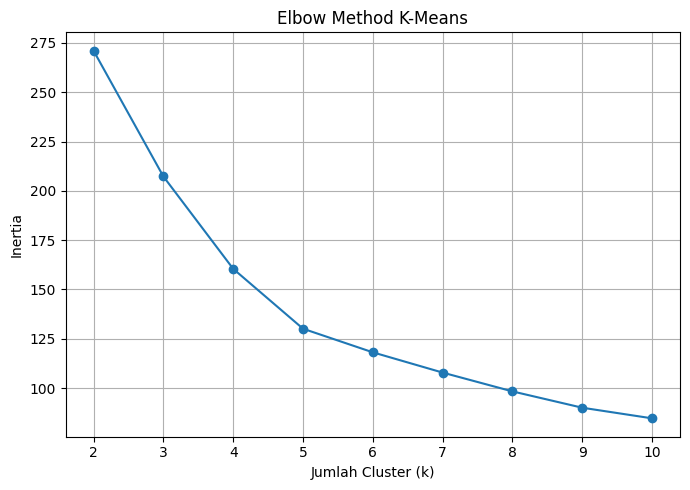

In [12]:
# Plot elbow
plt.figure(figsize=(7,5))
plt.plot(
    k_range,
    inertia,
    marker='o'
)

plt.title('Elbow Method K-Means')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# Check Silhouette Score
for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(
        X_cluster_scaled
    )
    score = silhouette_score(
        X_cluster_scaled,
        labels
    )
    print(f"k={k} | silhouette={score:.4f}")

k=2 | silhouette=0.3479
k=3 | silhouette=0.3405
k=4 | silhouette=0.3725
k=5 | silhouette=0.3364
k=6 | silhouette=0.2908
k=7 | silhouette=0.2942
k=8 | silhouette=0.2971
k=9 | silhouette=0.2963
k=10 | silhouette=0.2874


In [14]:
# Final model
best_k = 5
kmeans_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_model.fit_predict(
    X_cluster_scaled
)

In [15]:
# Interpretasi cluster
# Cluster 0 = Luas panen sedang, cuaca cukup sejuk, kelembaban tinggi (Wilayah Penyangga).
# Cluster 1 = Luas panen paling kecil, curah hujan & kelembaban paling tinggi, paling sejuk (Wilayah Pegunungan/Hulu).
# Cluster 2 = Luas panen paling besar/masif, curah hujan tinggi, hari kering sangat pendek (Lumbung Pangan Utama).
# Cluster 3 = Luas panen rendah, curah hujan tinggi, suhu paling panas (Wilayah Dataran Rendah/Pesisir).
# Cluster 4 = Luas panen besar nomor dua, curah hujan paling rendah, hari kering paling panjang (Sentra Lahan Kering).

df_cluster['cluster'] = cluster_labels
print(df_cluster['cluster'].value_counts())

cluster
1    720
0    677
2    423
3    233
4    198
Name: count, dtype: int64


In [16]:
# Segmentasi wilayah
# wilayah_segmentation = df_cluster[[
#     'kabupaten_kota_asli',
#     'tahun',
#     'cluster'
# ]]

# print(wilayah_segmentation.head(20))

In [17]:
cluster_summary = df_cluster.groupby('cluster')[
    cluster_features
].mean()

print(cluster_summary)

         luas_panen_ha  T2M_min_tahun  max_consecutive_dry_MK  RH2M_mean_tahun
cluster                                                                       
0             0.068376       0.850204                0.126354         0.389013
1             0.079986       0.663755                0.075149         0.765529
2             0.113482       0.315617                0.107801         0.794699
3             0.196515       0.674245                0.662138         0.224260
4             0.609758       0.670325                0.154718         0.584010


In [18]:
# Save model k-means
joblib.dump(
    kmeans_model,
    os.path.join(
        MODEL_FOLDER,
        'kmeans_model.joblib'
    )
)

print("KMeans model berhasil disimpan.")

KMeans model berhasil disimpan.
